# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, math, time, subprocess
import numpy as np, torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Thư mục gốc repo (chứa data/ và scripts/): ".." khi chạy trong code/ của repo, "../.." khi chạy trong submission_<MSSV>/code/
REPO_ROOT = next((p for p in ("..", "../..") if os.path.exists(f"{p}/scripts/split_data.py")), "../..")
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

# GPU CUDA nếu có (Colab/Kaggle). Không có CUDA thì dùng CPU: trên Mac M4 đã đo MPS CHẬM hơn CPU với MLP nhỏ này
# (~1.5 s so với ~0.4 s mỗi epoch) vì chi phí gọi kernel lấn át lượng tính toán.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device,
      "|", torch.cuda.get_device_name(0) if device == "cuda" else f"CPU, {torch.get_num_threads()} luồng")
print("REPO_ROOT =", os.path.abspath(REPO_ROOT), "| OUT_DIR =", os.path.abspath(OUT_DIR))
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import (DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval,
                   compute_loss, macro_f1_from_confusion)
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

torch 2.8.0 | device: cpu | CPU, 4 luồng
REPO_ROOT = /Users/tienanh211/K4-Track4-Day1-DinhLenhTienAnh-2A202602928-Neuralnetwork | OUT_DIR = /Users/tienanh211/K4-Track4-Day1-DinhLenhTienAnh-2A202602928-Neuralnetwork/submission_2A202602928


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
# 1. Chia train/eval theo metadata có sẵn (không sửa metadata). Script tự kiểm tra toàn vẹn và in tỉ lệ lớp.
out = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True, capture_output=True, text=True)
print(out.stdout)

# 2-4. Tách val 20% từ train (phân tầng, seed 42) -> chuẩn hoá 10 cột số bằng mean/std của phần train còn lại
#      -> đưa toàn bộ tensor lên device một lần (không DataLoader)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876



train 371,847 | val 92,962 | eval 116,203  (device=cpu)
"luôn đoán lớp 1" trên val: accuracy = 0.4876


In [3]:
# Tự kiểm tra Part 0
X_tr, y_tr, X_val, y_val = data["X_tr"], data["y_tr"], data["X_val"], data["y_val"]
y_eval = data["y_eval"]   # chỉ dùng để so tỉ lệ lớp; X_eval không đi vào bước chuẩn hoá/chọn cấu hình nào
assert (len(X_tr), len(X_val), len(data["X_eval"])) == (371_847, 92_962, 116_203)
assert X_tr.dtype == torch.float32 and y_tr.dtype == torch.int64 and X_tr.shape[1] == 54

# (a) tỉ lệ lớp ở train / val / eval
props = {n: torch.bincount(y, minlength=7).cpu().numpy() / len(y) for n, y in (("train", y_tr), ("val", y_val), ("eval", y_eval))}
print("lớp    train%     val%    eval%")
for c in range(7):
    print(f"{c:>3d}  " + "  ".join(f"{100 * props[n][c]:7.3f}" for n in props))

# (b) 10 cột số: mean/std trên phần train còn lại phải ≈ 0 / 1; 44 cột nhị phân giữ nguyên {0, 1}
num = X_tr[:, :10].double()
print("\nmean 10 cột số (train):", np.round(num.mean(0).cpu().numpy(), 4))
print("std  10 cột số (train):", np.round(num.std(0).cpu().numpy(), 4))
print("std  10 cột số (val)  :", np.round(X_val[:, :10].double().std(0).cpu().numpy(), 4), " (dùng mean/std của train nên chỉ ≈ 1)")
assert num.mean(0).abs().max() < 1e-4 and (num.std(0) - 1).abs().max() < 1e-3
assert set(torch.unique(X_tr[:, 10:]).tolist()) == {0.0, 1.0}

# (c) mốc thấp nhất: "luôn đoán lớp đa số" (lớp đa số xác định trên train) trên val
maj = int(torch.bincount(y_tr).argmax())
cm_maj = np.zeros((7, 7), dtype=np.int64)
cm_maj[:, maj] = np.bincount(y_val.cpu().numpy(), minlength=7)
MAJ_ACC = float((y_val == maj).float().mean())
MAJ_F1 = macro_f1_from_confusion(cm_maj)
print(f'\n"luôn đoán lớp {maj}" trên val: accuracy = {MAJ_ACC:.4f}, macro-F1 = {MAJ_F1:.4f}')

lớp    train%     val%    eval%
  0   36.461   36.460   36.460
  1   48.760   48.760   48.760
  2    6.154    6.154    6.154
  3    0.473    0.472    0.472
  4    1.634    1.634    1.634
  5    2.989    2.989    2.989
  6    3.530    3.530    3.530

mean 10 cột số (train): [-0. -0. -0.  0. -0. -0. -0. -0. -0.  0.]
std  10 cột số (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
std  10 cột số (val)  : [0.9981 1.0011 0.9981 1.0037 0.9995 1.0043 1.0009 0.9998 0.9993 1.0035]  (dùng mean/std của train nên chỉ ≈ 1)



"luôn đoán lớp 1" trên val: accuracy = 0.4876, macro-F1 = 0.0936


**Nhận xét Part 0:**
- Kích thước khớp yêu cầu: train 464 809 → **371 847 train + 92 962 val** (20%, phân tầng, `random_state=42`); eval 116 203. Tỉ lệ lớp ở ba tập gần như trùng nhau (chênh < 0,01 điểm %) nhờ phân tầng. Dữ liệu rất mất cân bằng: lớp 1 chiếm 48,8%, lớp 3 chỉ 0,47%.
- Sau chuẩn hoá, 10 cột số trên phần train còn lại có mean = 0, std = 1. Trên val, std chỉ **xấp xỉ** 1 vì val dùng lại mean/std của train. 44 cột one-hot giữ nguyên giá trị {0, 1}.
- Mốc thấp nhất: "luôn đoán lớp 1" có val accuracy **0,4876** nhưng macro-F1 chỉ **0,0937**. Mọi mô hình phải vượt mốc này, và macro-F1 mới phản ánh đúng chất lượng trên các lớp hiếm.
- **Vì sao chỉ tính mean/std trên phần train?** Val và eval đóng vai dữ liệu "chưa thấy". Nếu dùng thống kê của chúng để chuẩn hoá thì thông tin về phân phối của tập đánh giá đã rò vào bước tiền xử lý (rò rỉ dữ liệu), làm điểm val/eval lạc quan hơn thực tế. Khi triển khai thật, ta cũng chỉ có thống kê của dữ liệu huấn luyện. Trong code, `fit_standardizer` chỉ nhận `X_tr`, còn `X_eval` chỉ được *áp dụng* cùng mean/std đó và không tham gia chuẩn hoá, chọn cấu hình hay dừng sớm.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [4]:
# 1a-1b. Model M-base: 54 -> 256 -> 128 -> 7, ReLU, He init, không dropout; kiểm tra số tham số và shape
set_seed(1)   # cùng seed với base-s1 ở Part 2 -> cùng trọng số khởi tạo
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879
print(model)
print(f"số tham số: {n_params:,}\n")

xb8 = torch.randn(8, 54, device=device)
h = xb8
print(f"{'input':<45s} {tuple(h.shape)}")
for layer in model.net:
    h = layer(h)
    print(f"{str(layer):<45s} {tuple(h.shape)}")
logits = model(xb8)
assert logits.shape == (8, 7) and logits.dtype == torch.float32

# He init thật sự được áp dụng (không phải mặc định của nn.Linear): std(W) ≈ sqrt(2 / n_vào), bias = 0
print()
for i, lin in enumerate((l for l in model.net if isinstance(l, nn.Linear)), 1):
    print(f"W{i}: std = {lin.weight.std().item():.4f}  (He: sqrt(2/{lin.in_features}) = {math.sqrt(2 / lin.in_features):.4f}),"
          f"  b{i} toàn 0: {bool((lin.bias == 0).all())}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47,879

input                                         (8, 54)
Linear(in_features=54, out_features=256, bias=True) (8, 256)
ReLU()                                        (8, 256)
Linear(in_features=256, out_features=128, bias=True) (8, 128)
ReLU()                                        (8, 128)
Linear(in_features=128, out_features=7, bias=True) (8, 7)

W1: std = 0.1938  (He: sqrt(2/54) = 0.1925),  b1 toàn 0: True
W2: std = 0.0883  (He: sqrt(2/256) = 0.0884),  b2 toàn 0: True
W3: std = 0.1230  (He: sqrt(2/128) = 0.1250),  b3 toàn 0: True


In [5]:
# 1c-1. Loss bước 0 trên val (eval mode, chưa cập nhật lần nào), kỳ vọng ≈ ln 7
LN7 = math.log(7)
step0 = evaluate(model, X_val, y_val)["loss"]
print(f"loss bước 0 = {step0:.4f}   ln 7 = {LN7:.4f}   lệch = {step0 - LN7:+.4f}")
print("std sau mỗi Linear (lớp cuối = logits):", [round(s, 3) for s in activation_stats(model, X_val)])

# Chẩn đoán độ lệch: lặp lại với 5 seed; rồi thu nhỏ W của lớp ra x0.01 (logits ≈ 0, mọi thứ khác giữ nguyên).
# Nếu lệch là do thang khởi tạo của lớp ra (không phải lỗi code) thì loss phải về ≈ ln 7.
print(f"\n{'seed':>4s} {'step0 (He)':>11s} {'std logits':>11s} {'W_out x0.01':>12s}")
for s in range(1, 6):
    set_seed(s)
    m = MLP((256, 128), init="he").to(device)
    l_he, z_std = evaluate(m, X_val, y_val)["loss"], activation_stats(m, X_val)[-1]
    with torch.no_grad():
        m.net[-1].weight.mul_(0.01)
    print(f"{s:>4d} {l_he:>11.4f} {z_std:>11.3f} {evaluate(m, X_val, y_val)['loss']:>12.4f}")

loss bước 0 = 2.2691   ln 7 = 1.9459   lệch = +0.3232
std sau mỗi Linear (lớp cuối = logits): [0.659, 0.639, 0.579]

seed  step0 (He)  std logits  W_out x0.01
   1      2.2691       0.579       1.9477


   2      1.9782       0.545       1.9449


   3      1.9005       0.533       1.9442
   4      2.3106       0.560       1.9482


   5      2.1444       0.559       1.9467


nhãn của 20 mẫu: [1, 1, 0, 0, 1, 1, 0, 0, 1, 6, 1, 0, 2, 1, 5, 0, 0, 1, 0, 1]


loss bước 1 = 2.3581, bước 100 = 5.99e-04, bước 500 = 1.72e-04; accuracy trên 20 mẫu = 100%


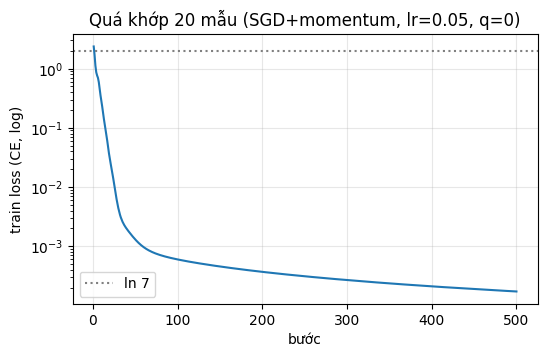

In [6]:
# 1c-2. Quá khớp 20 mẫu: tắt dropout (q = 0), cùng model/hàm loss/optimizer như baseline, 500 bước full-batch
g = torch.Generator().manual_seed(0)
idx20 = torch.randperm(len(X_tr), generator=g)[:20].to(device)
xb20, yb20 = X_tr[idx20], y_tr[idx20]
print("nhãn của 20 mẫu:", yb20.tolist())

set_seed(1)
m20 = MLP((256, 128), dropout=0.0, init="he").to(device)
opt20 = build_optimizer("sgd_momentum", m20.parameters(), lr=0.05)   # lr chỉ dùng cho phép thử này
losses20 = []
for step in range(500):
    m20.train()
    loss = compute_loss(m20(xb20), yb20, "ce")
    opt20.zero_grad(set_to_none=True)
    loss.backward()
    opt20.step()
    losses20.append(loss.item())
acc20 = (predict(m20, xb20) == yb20).float().mean().item()
print(f"loss bước 1 = {losses20[0]:.4f}, bước 100 = {losses20[99]:.2e}, bước 500 = {losses20[-1]:.2e}; accuracy trên 20 mẫu = {acc20:.0%}")
assert losses20[-1] < 1e-2 and acc20 == 1.0

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(range(1, 501), losses20)
ax.axhline(LN7, color="gray", ls=":", label="ln 7")
ax.set(title="Quá khớp 20 mẫu (SGD+momentum, lr=0.05, q=0)", xlabel="bước", ylabel="train loss (CE, log)")
ax.grid(alpha=0.3); ax.legend()
plt.show()

In [7]:
# 1d. Gradient có chảy tới mọi tham số? Một lần forward/backward trên 512 mẫu train
model.train()
model.zero_grad(set_to_none=True)
compute_loss(model(X_tr[:512]), y_tr[:512], "ce").backward()
for i, lin in enumerate((l for l in model.net if isinstance(l, nn.Linear)), 1):
    for name, p in ((f"W{i}", lin.weight), (f"b{i}", lin.bias)):
        assert p.grad is not None and p.grad.norm() > 0, f"{name} không có gradient"
        print(f"{name:3s} {str(tuple(p.shape)):11s} ‖grad‖ = {p.grad.norm().item():.4e}")
print("chuẩn toàn cục:", f"{clip_gradients(model.parameters(), None):.4f}")
model.zero_grad(set_to_none=True)

W1  (256, 54)   ‖grad‖ = 5.0705e-01
b1  (256,)      ‖grad‖ = 3.4224e-01
W2  (128, 256)  ‖grad‖ = 2.0212e+00
b2  (128,)      ‖grad‖ = 4.4387e-01
W3  (7, 128)    ‖grad‖ = 1.9605e+00
b3  (7,)        ‖grad‖ = 5.7246e-01
chuẩn toàn cục: 2.9711


**Nhận xét Part 1:**
- **Model:** 47 879 tham số (assert qua), logits có shape `(8, 7)` và không có softmax trong model. std(W) khớp với He: W1 0,194 so với √(2/54) = 0,192, W2 0,088 so với 0,088, W3 0,123 so với 0,125, bias đều bằng 0. Vậy khởi tạo He thực sự được áp dụng, không phải khởi tạo mặc định của `nn.Linear`.
- **Loss bước 0** đo được là **2,2691** (seed 1), so với ln 7 = 1,9459 thì lệch +0,32. Qua 5 seed, giá trị này dao động từ 1,90 đến 2,31, quanh ln 7. Lý do: ln 7 chỉ đúng khi logits ≈ 0, tức softmax đều trên 7 lớp. He init cho lớp ra Var = 2/128, nên logits có std ≈ 0,53–0,58 (đo bằng `activation_stats`). Khi đó loss bước 0 = E[logsumexp(z)] − E[z_y]: mỗi seed vô tình "ưu ái" một số lớp, và vì nhãn mất cân bằng (lớp 0 và 1 chiếm 85%), loss cao hơn ln 7 khi init bất lợi cho các lớp lớn (seed 1, 4) và thấp hơn khi init có lợi cho chúng (seed 3). **Bằng chứng đây không phải lỗi code:** chỉ cần thu nhỏ W lớp ra ×0,01 (mọi thứ khác giữ nguyên), loss về **1,944–1,948 ≈ ln 7** ở cả 5 seed. Nếu nhãn lệch hay softmax bị áp hai lần thì phép thu nhỏ này không sửa được. Baseline vẫn giữ He cho mọi lớp đúng như quy định. Độ lệch này biến mất rất nhanh: sau epoch 1, val loss đã ≈ 0,48.
- **Quá khớp 20 mẫu** (q = 0, SGD+momentum lr 0,05): loss giảm từ 2,358 xuống 6,0·10⁻⁴ sau 100 bước và 1,7·10⁻⁴ sau 500 bước, accuracy 100%. Như vậy nhãn, hàm loss, `zero_grad` và việc optimizer nhận đủ tham số đều đúng, và mạng đủ năng lực ghi nhớ.
- **Gradient chảy tới mọi tham số:** cả 6 tensor W1, b1, …, b3 đều có ‖grad‖ khác 0, từ 0,34 (b1) đến 2,02 (W2), chuẩn toàn cục 2,97. Không có lớp nào bị "đứt" gradient.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

### 2a. `run_experiment(cfg, data)` (code ở `train.py`)
Mọi lần chạy chỉ khác nhau ở dict `cfg`. Mỗi epoch hàm ghi các giá trị sau:
- `train_loss` đo ở chế độ `eval()` trên **toàn bộ** 371 847 mẫu train, để so trực tiếp được với `val_loss`. Kèm theo `val_loss`, `val_acc`, `val_macro_f1` (cùng định nghĩa với `scripts/evaluate.py`).
- `grad_norm`: chuẩn L2 toàn cục, **đo trước khi clip** (`clip_grad_norm_` trả về giá trị trước khi cắt), lấy trung bình mỗi epoch. Kèm `grad_norm_max` để thấy "gai" và `clip_frac` là tỉ lệ bước bị cắt.
- `epoch_time_s`: chỉ tính phần huấn luyện, có đồng bộ GPU trước khi đo. `peak_mem_MB` chỉ có trên CUDA (CPU/MPS ghi `None`).
- `step0_loss` đo trên val trước bước cập nhật đầu tiên. `best_epoch` là epoch có val loss thấp nhất (đóng vai dừng sớm), và các metric trong `summary` lấy tại epoch đó. Trọng số của epoch này giữ trong `best_state`.
- Cờ `diverged`: nếu loss thành NaN/inf thì dừng ngay và ghi lại.

Một số quyết định: lô cuối nhỏ hơn 512 (371 847 = 726×512 + 135) vẫn được giữ lại. Thứ tự lô chỉ phụ thuộc `seed` (hoán vị sinh trên CPU). Loss luôn tính ở FP32. Sau mỗi lần chạy, kết quả được ghi vào `../results/<exp_id>.json` và ảnh vào `../figures/<exp_id>.png`.

### 2b. Chọn `lr` cho baseline (chỉ bằng val)
Các giá trị thử: 0.003, 0.01, 0.03, 0.1, 0.3 (cách nhau khoảng 3 lần). Mọi thứ khác giữ như baseline (seed 1, 20 epoch). Mỗi lần chạy là một dòng trong bảng (nhóm `hparam`).

**Dự đoán trước khi chạy:** lr = 0.003 quá nhỏ nên sau 20 epoch vẫn chưa hội tụ (val loss còn giảm đều). Với momentum 0,9, bước hiệu dụng là khoảng η/(1−μ) = 10η, nên lr = 0.3 (bước hiệu dụng ≈ 3) có thể làm loss dao động mạnh hoặc phân kỳ. Tôi đoán lr tốt nhất nằm trong khoảng 0.03 đến 0.1.

[lr-sgdm-0.003] step0 2.2691 | best ep 20 val_loss 0.4167 acc 0.8273 f1 0.6754 | 0.34s/epoch


[lr-sgdm-0.01] step0 2.2691 | best ep 19 val_loss 0.3179 acc 0.8717 f1 0.7656 | 0.34s/epoch


[lr-sgdm-0.03] step0 2.2691 | best ep 20 val_loss 0.2631 acc 0.8929 f1 0.8249 | 0.34s/epoch


[lr-sgdm-0.1] step0 2.2691 | best ep 20 val_loss 0.2376 acc 0.9057 f1 0.8560 | 0.34s/epoch


[lr-sgdm-0.3] step0 2.2691 | best ep 20 val_loss 0.2294 acc 0.9094 f1 0.8503 | 0.34s/epoch

    lr   step0 best_ep best_val_loss final_train final_val  val_acc  val_f1 s/epoch
 0.003  2.2691      20        0.4167      0.4104    0.4167   0.8273  0.6754    0.34
  0.01  2.2691      19        0.3179      0.3191    0.3299   0.8717  0.7656    0.34
  0.03  2.2691      20        0.2631      0.2466    0.2631   0.8929  0.8249    0.34
   0.1  2.2691      20        0.2376      0.2144    0.2376   0.9057  0.8560    0.34
   0.3  2.2691      20        0.2294      0.2045    0.2294   0.9094  0.8503    0.34

-> lr chọn cho baseline (val macro-F1 cao nhất): 0.1


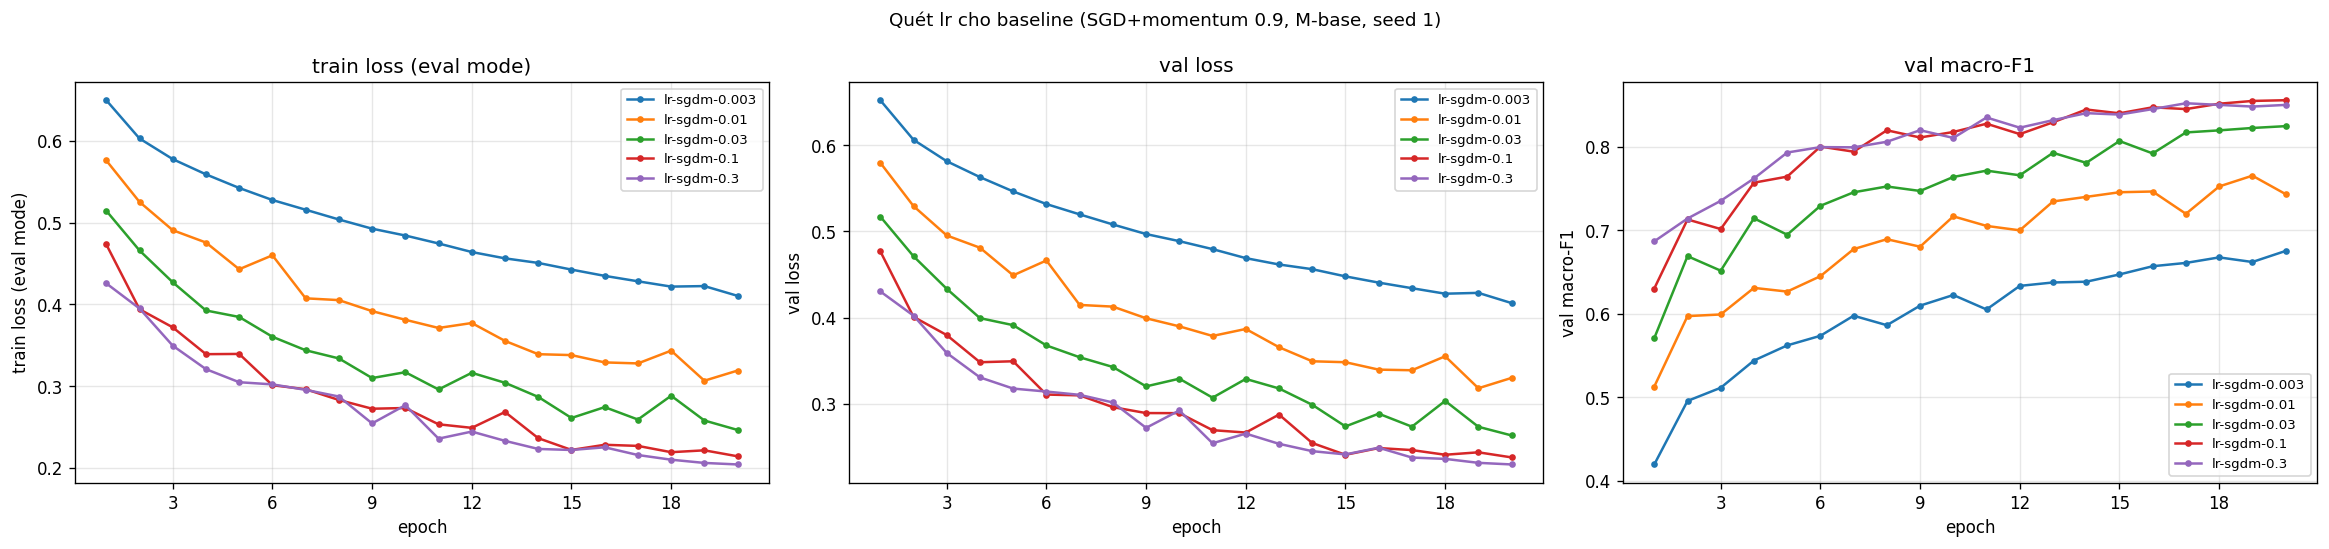

In [8]:
# 2b-1. Quét lr cho SGD+momentum, chọn theo val macro-F1 (chỉ số chính), seed 1, 20 epoch
LRS = [0.003, 0.01, 0.03, 0.1, 0.3]
lr_runs = {}
for lr in LRS:
    r = run_experiment({**DEFAULT_CFG, "lr": lr, "seed": 1, "exp_id": f"lr-sgdm-{lr:g}", "group": "hparam",
                        "description": f"Tìm lr cho baseline: SGD+momentum lr={lr:g}, còn lại như baseline"}, data)
    save_result(r, f"{OUT_DIR}/results")
    plot_run(r, f"{OUT_DIR}/figures/{r['cfg']['exp_id']}.png")
    lr_runs[lr] = r

print(f"\n{'lr':>6s} {'step0':>7s} {'best_ep':>7s} {'best_val_loss':>13s} {'final_train':>11s} {'final_val':>9s} "
      f"{'val_acc':>8s} {'val_f1':>7s} {'s/epoch':>7s}")
for lr, r in lr_runs.items():
    s = r["summary"]
    if s["diverged"] and s["best_epoch"] is None:
        print(f"{lr:>6g}  phân kỳ ngay epoch đầu"); continue
    print(f"{lr:>6g} {s['step0_loss']:>7.4f} {s['best_epoch']:>7d} {s['best_val_loss']:>13.4f} {s['final_train_loss']:>11.4f} "
          f"{s['final_val_loss']:>9.4f} {s['val_acc']:>8.4f} {s['val_macro_f1']:>7.4f} {s['time_per_epoch_s']:>7.2f}"
          + ("  DIVERGED" if s["diverged"] else ""))

ok = {lr: r for lr, r in lr_runs.items() if not r["summary"]["diverged"]}
BEST_LR = max(ok, key=lambda lr: ok[lr]["summary"]["val_macro_f1"])
print(f"\n-> lr chọn cho baseline (val macro-F1 cao nhất): {BEST_LR:g}")
if BEST_LR != DEFAULT_CFG["lr"]:
    print(f"   Lưu ý: khác DEFAULT_CFG['lr'] = {DEFAULT_CFG['lr']:g} trong train.py; notebook dùng BEST_LR, nên cập nhật train.py cho khớp.")

plot_compare(list(lr_runs.values()), ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_lr_sgdm.png",
             title="Quét lr cho baseline (SGD+momentum 0.9, M-base, seed 1)")
display(Image(f"{OUT_DIR}/figures/compare_lr_sgdm.png"))

  ep  1  train 0.4733  val 0.4769  acc 0.7920  f1 0.6304  |g| 0.530  0.3s


  ep  2  train 0.3940  val 0.4008  acc 0.8289  f1 0.7131  |g| 0.562  0.3s


  ep  3  train 0.3720  val 0.3796  acc 0.8439  f1 0.7017  |g| 0.593  0.3s


  ep  4  train 0.3392  val 0.3481  acc 0.8542  f1 0.7572  |g| 0.584  0.3s


  ep  5  train 0.3395  val 0.3492  acc 0.8536  f1 0.7644  |g| 0.579  0.3s


...

  ep 20  train 0.2144  val 0.2376  acc 0.9057  f1 0.8560  |g| 0.558  0.3s
[base-s1] step0 2.2691 | best ep 20 val_loss 0.2376 acc 0.9057 f1 0.8560 | 0.34s/epoch


[base-s2] step0 1.9782 | best ep 20 val_loss 0.2283 acc 0.9090 f1 0.8568 | 0.34s/epoch


[base-s3] step0 1.9005 | best ep 19 val_loss 0.2320 acc 0.9081 f1 0.8583 | 0.34s/epoch


[base-s4] step0 2.3106 | best ep 20 val_loss 0.2293 acc 0.9080 f1 0.8510 | 0.34s/epoch


[base-s5] step0 2.1444 | best ep 20 val_loss 0.2225 acc 0.9116 f1 0.8581 | 0.34s/epoch

tái lập: |Δ val_loss| lớn nhất giữa base-s1 và lr-sgdm-0.1 (cùng cfg, cùng seed) = 0.00e+00


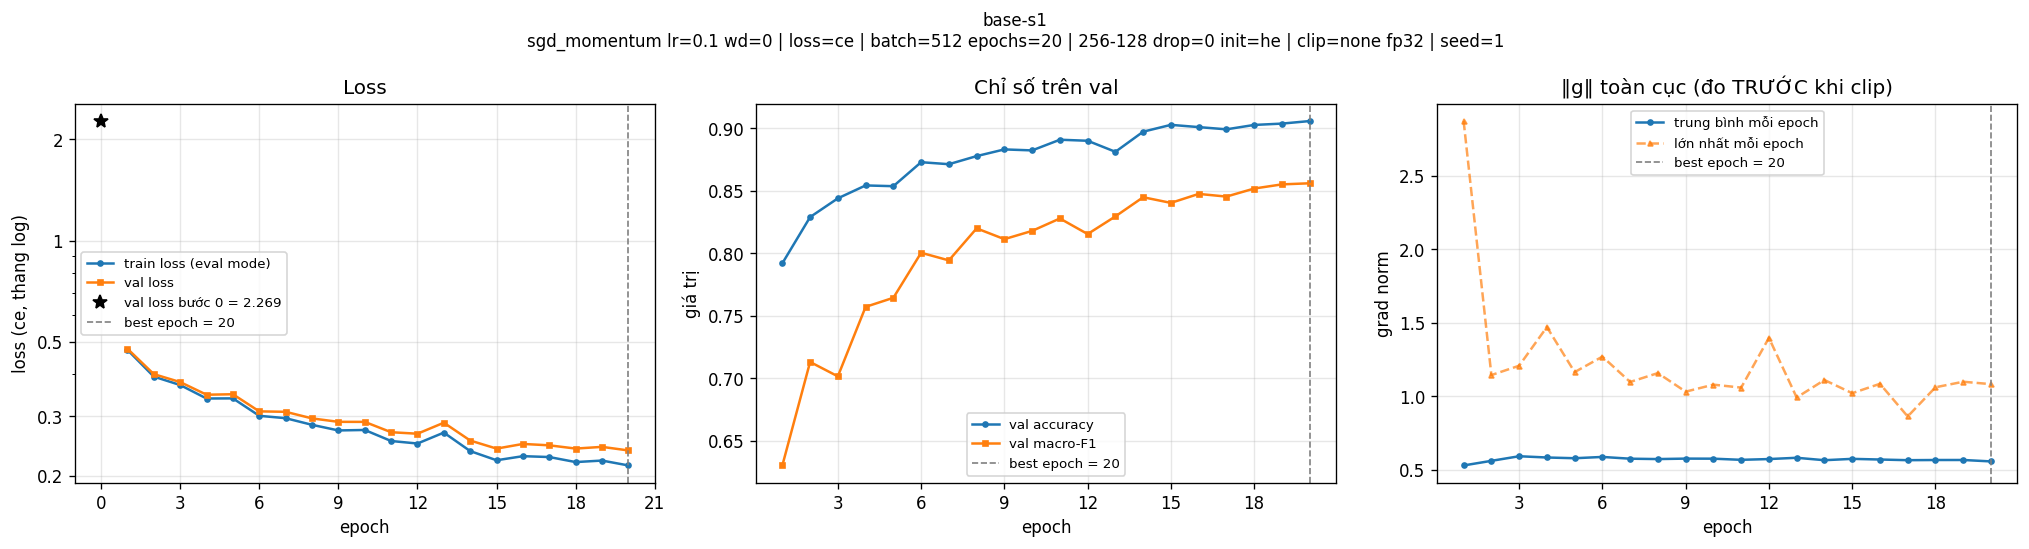

In [9]:
# 2b-2. Baseline với lr đã chọn, 5 seed để đo độ nhiễu (seed đổi cả khởi tạo lẫn thứ tự lô; phép tách val giữ nguyên)
cfg = {**DEFAULT_CFG, "lr": BEST_LR}
SEEDS = [1, 2, 3, 4, 5]
base_runs = []
for s in SEEDS:
    r = run_experiment({**cfg, "seed": s, "exp_id": f"base-s{s}", "description": f"Baseline M-base, seed {s}"},
                       data, verbose=(s == 1))
    save_result(r, f"{OUT_DIR}/results")
    plot_run(r, f"{OUT_DIR}/figures/{r['cfg']['exp_id']}.png")
    base_runs.append(r)

# base-s1 trùng cấu hình và seed với lr-sgdm-<BEST_LR> -> kiểm tra tính tái lập
d = max(abs(a - b) for a, b in zip(base_runs[0]["history"]["val_loss"], lr_runs[BEST_LR]["history"]["val_loss"]))
print(f"\ntái lập: |Δ val_loss| lớn nhất giữa base-s1 và lr-sgdm-{BEST_LR:g} (cùng cfg, cùng seed) = {d:.2e}")
display(Image(f"{OUT_DIR}/figures/base-s1.png"))

  exp_id    best_val_loss       best_epoch final_train_loss   final_val_loss          val_acc     val_macro_f1
 base-s1           0.2376          20.0000           0.2144           0.2376           0.9057           0.8560
 base-s2           0.2283          20.0000           0.2045           0.2283           0.9090           0.8568
 base-s3           0.2320          19.0000           0.2224           0.2469           0.9081           0.8583
 base-s4           0.2293          20.0000           0.2084           0.2293           0.9080           0.8510
 base-s5           0.2225          20.0000           0.2031           0.2225           0.9116           0.8581
 best_val_loss: 0.2299 ± 0.0055   (2σ = 0.0110, min-max = 0.2225-0.2376)
       val_acc: 0.9085 ± 0.0021   (2σ = 0.0043, min-max = 0.9057-0.9116)
  val_macro_f1: 0.8560 ± 0.0030   (2σ = 0.0059, min-max = 0.8510-0.8583)

khoảng cách val − train loss ở epoch cuối: 0.0224 ± 0.0022; best_epoch: [19, 20, 20, 20, 20]
vượt mốc 'đoán đa số'

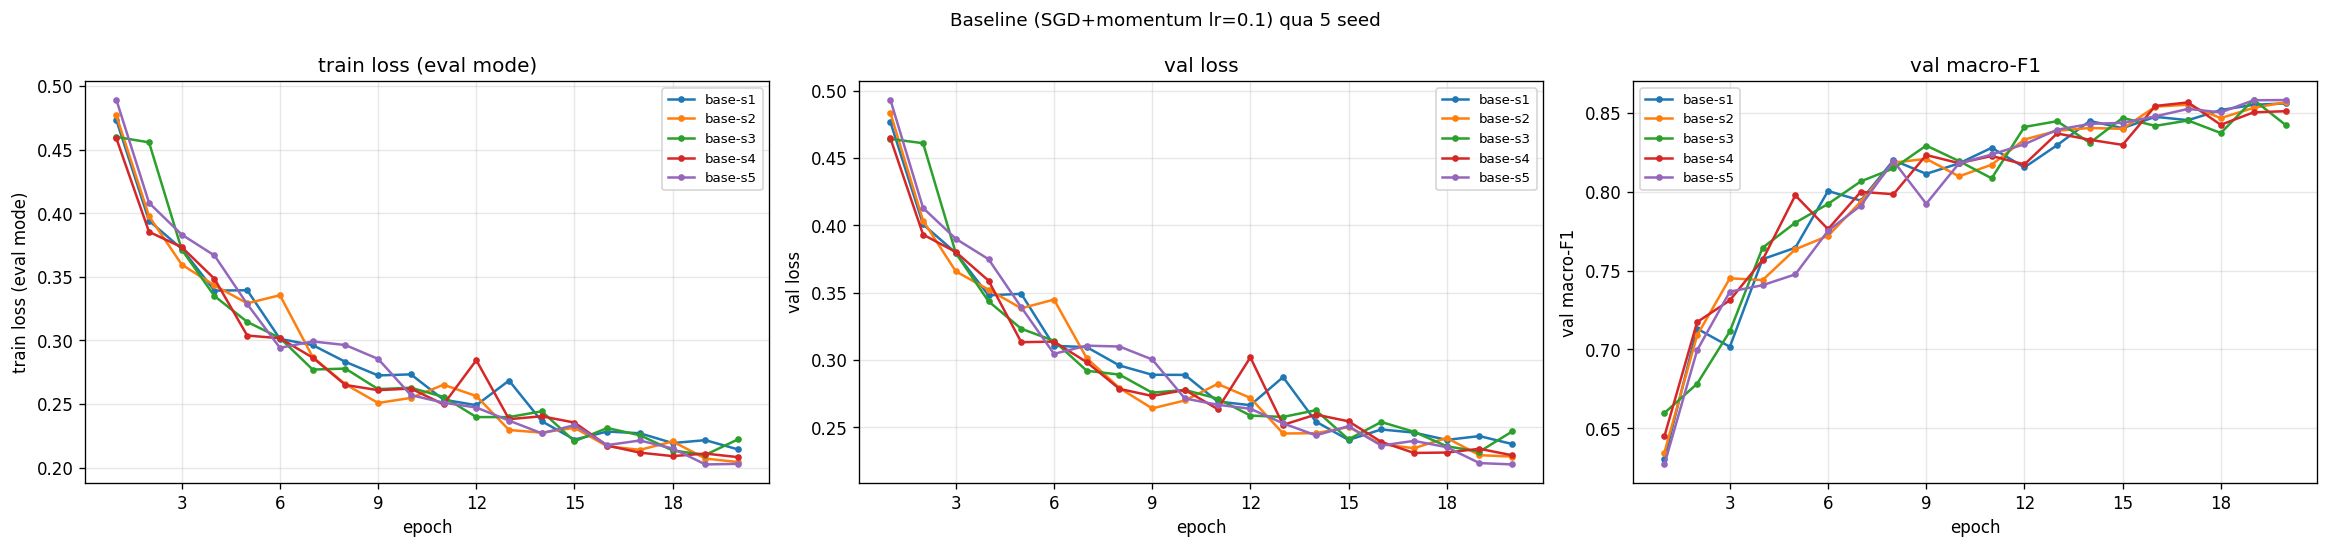

In [10]:
# 2b-3. Độ nhiễu giữa các seed: mean ± std (std mẫu, ddof=1, giống STDEV trong sheet Seeds) và ngưỡng 2σ
cols = ["best_val_loss", "best_epoch", "final_train_loss", "final_val_loss", "val_acc", "val_macro_f1"]
print(f"{'exp_id':>8s} " + " ".join(f"{c:>16s}" for c in cols))
for r in base_runs:
    print(f"{r['cfg']['exp_id']:>8s} " + " ".join(f"{r['summary'][c]:>16.4f}" for c in cols))

NOISE = {}
for c in ["best_val_loss", "val_acc", "val_macro_f1"]:
    v = np.array([r["summary"][c] for r in base_runs])
    NOISE[c] = dict(mean=v.mean(), std=v.std(ddof=1), two_sigma=2 * v.std(ddof=1))
    print(f"{c:>14s}: {v.mean():.4f} ± {v.std(ddof=1):.4f}   (2σ = {2 * v.std(ddof=1):.4f}, min-max = {v.min():.4f}-{v.max():.4f})")
gap = np.array([r["summary"]["final_val_loss"] - r["summary"]["final_train_loss"] for r in base_runs])
print(f"\nkhoảng cách val − train loss ở epoch cuối: {gap.mean():.4f} ± {gap.std(ddof=1):.4f}; "
      f"best_epoch: {sorted(r['summary']['best_epoch'] for r in base_runs)}")
print(f"vượt mốc 'đoán đa số'? val_acc thấp nhất {min(r['summary']['val_acc'] for r in base_runs):.4f} > {MAJ_ACC:.4f}")
gn = np.array([r["history"]["grad_norm"] for r in base_runs])
gmax = np.array([r["history"]["grad_norm_max"] for r in base_runs])
print(f"grad_norm baseline (trước clip): trung bình epoch 1 = {gn[:, 0].mean():.3f}, epoch 20 = {gn[:, -1].mean():.3f}; "
      f"lớn nhất mọi bước = {gmax.max():.3f}  (tham khảo khi chọn c cho clipping ở Part 3)")

plot_compare(base_runs, ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_baseline_seeds.png",
             title=f"Baseline (SGD+momentum lr={BEST_LR:g}) qua {len(SEEDS)} seed")
display(Image(f"{OUT_DIR}/figures/compare_baseline_seeds.png"))

**Nhận xét chọn lr (nhóm `hparam`, so với dự đoán):**
- lr = 0,003 và 0,01 **chưa hội tụ** sau 20 epoch: val loss còn giảm đều (0,417 và 0,318–0,330), val macro-F1 chỉ đạt 0,675 và 0,766. Điều này khớp dự đoán: bước nhỏ nên 20 epoch (≈ 14 500 bước) là chưa đủ.
- lr = 0,03 đạt 0,825. lr = 0,1 đạt val macro-F1 **cao nhất, 0,8560** (val loss 0,2376). lr = 0,3 có val loss **thấp nhất (0,2294)** nhưng macro-F1 là 0,8503.
- **Dự đoán sai ở lr = 0,3:** tôi dự đoán loss sẽ dao động hoặc phân kỳ, nhưng thực tế không phân kỳ và đường cong còn mượt như lr = 0,1. Phỏng đoán (chưa kiểm chứng): mạng nông, đầu vào đã chuẩn hoá, và ‖g‖ trung bình ở lr = 0,3 chỉ 0,34–0,40 (đo được), nên bước hiệu dụng ≈ 3 vẫn nằm trong vùng ổn định. Ngưỡng phân kỳ có lẽ cao hơn (chưa thử lr ≥ 1 với SGD+momentum).
- **lr = 0,1 và 0,3 chưa phân biệt được:** chênh lệch val macro-F1 là 0,0057, nhỏ hơn 2σ_seed = 0,0059 (đo bên dưới), và val loss lại xếp hạng ngược chiều. Tôi chọn **lr = 0,1** theo tiêu chí đặt trước khi chạy (val macro-F1 cao nhất, chỉ số chính), cũng là lựa chọn thận trọng hơn về ổn định. Hạn chế: mỗi lr chỉ chạy 1 seed và chưa thử lr > 0,3.

**Nhận xét baseline** (M-base, SGD+momentum 0,9, lr 0,1, He, CE, batch 512, 20 epoch, 5 seed):
- **Vượt xa mốc "đoán đa số":** val accuracy **0,9085 ± 0,0021** so với 0,4876; val macro-F1 **0,8560 ± 0,0030** so với 0,0936.
- **Hình dạng đường cong:** train loss và val loss (cả hai đo ở eval mode) giảm gần như song song. Khoảng cách val − train ở epoch cuối chỉ 0,022 ± 0,002, và `best_epoch` = 19–20 ở cả 5 seed. Mô hình **còn đang học và chưa quá khớp**: thiếu khớp theo thời gian huấn luyện, không phải theo dữ liệu. Huấn luyện lâu hơn, giảm lr dần hoặc dùng mạng rộng/sâu hơn có khả năng cải thiện. Dropout khó giúp ích vì chưa có quá khớp để chữa. Đường cong có vài "gai" ngắn (ví dụ epoch 13 của s1, epoch 12 của s4): đó là nhiễu của SGD với lr lớn, và đường cong hồi phục ngay ở epoch kế tiếp. Riêng s3 có gai đúng ở epoch 20, nên `best_epoch` của s3 là 19.
- **Độ nhiễu seed** (5 seed, std mẫu): val macro-F1 σ = 0,0030 nên **2σ = 0,0059**; val accuracy 2σ = 0,0043; best val loss 2σ = 0,0110. Ở Part 3, mọi chênh lệch nhỏ hơn các ngưỡng này **không được coi là bằng chứng**. Với 5 seed, σ vẫn chỉ là ước lượng thô. Macro-F1 nhiễu hơn accuracy (tương đối) vì lớp hiếm có ít mẫu trong val (lớp 3 chỉ ≈ 440 mẫu), nên vài mẫu đúng/sai cũng làm F1 của lớp đó dao động.
- **`grad_norm` (trước clip):** trung bình mỗi epoch ổn định quanh 0,50–0,59; giá trị lớn nhất mỗi lần chạy là 2,4–2,9 và ở cả 5 seed đều rơi vào epoch 1. Đây là căn cứ chọn ngưỡng c khi thí nghiệm clipping.
- **Tái lập:** `base-s1` trùng cấu hình và seed với `lr-sgdm-0.1`, và cho kết quả giống hệt (|Δ val_loss| = 0). Trên CPU pipeline tất định; trên GPU có thể lệch rất nhỏ.
- **Thời gian:** ≈ 0,34 s/epoch trên CPU (4 luồng). `peak_mem_MB` không đo được trên CPU (chỉ có trên CUDA), sẽ ghi vào `notes` của bảng.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm `<exp_id>` — chủ đề `<nhóm>`
**Dự đoán trước (viết TRƯỚC khi chạy):** ...

In [ ]:
# Mẫu một thí nghiệm. Lặp lại / bọc trong vòng for qua danh sách cfg bạn tự thiết kế.
# TODO: exp_cfg = {**cfg, "exp_id": "...", "group": "...", "description": "...", <chỉ đổi MỘT yếu tố>}
# TODO: result = run_experiment(exp_cfg, data)
# TODO: save_result(...); plot_run(...)   # mỗi thí nghiệm một ảnh figures/<exp_id>.png
# TODO: in summary (best_val_loss, val_acc, val_macro_f1, ...) và so với baseline + ngưỡng nhiễu 2σ

**Đối chiếu sau khi chạy:** khớp / khác dự đoán? vì sao (cơ chế)? chênh lệch có vượt 2σ không? ...

In [ ]:
# TODO: ảnh chồng theo nhóm: plot_compare(list_of_results_in_group, "val_loss", f"{OUT_DIR}/figures/compare_<nhóm>.png")

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [ ]:
# TODO: chọn cấu hình cuối cùng theo VAL (có thể là baseline nếu bạn không kết hợp thêm gì)
# TODO: final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")
# TODO: chạy: python scripts/evaluate.py --pred <OUT_DIR>/predictions_eval.csv --out <OUT_DIR>/eval_result.json (từ REPO_ROOT)
# TODO: đọc eval_result.json: ghi accuracy, macro_f1 vào bảng và báo cáo; làm tương tự cho baseline (predictions riêng, không nộp nếu không cần)

In [ ]:
# TODO: phân tích lỗi trên eval: bảng precision/recall/F1 theo lớp (từ eval_result.json) và ma trận nhầm lẫn;
#       lớp nào khó nhất? vì sao (số mẫu ít? nhầm với lớp nào?)  -> viết nhận xét ở ô markdown bên dưới

**Phân tích lỗi (tự viết):** ...

In [ ]:
# TODO: results = load_results(f"{OUT_DIR}/results"); rows = [to_row(r, ...) for r in results]
# TODO: write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
# TODO: bổ sung sheet Seeds (exp_id các lần chạy baseline) và nhận xét ở sheet Summary